# Binary classification (BENIGN , ATTACK)

In [3]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [4]:
df = pd.read_csv("../data/processed/cicids2017_clean.csv")

In [5]:
# Transformer toutes les attaques en une seule classe
df['Label'] = df['Label'].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK')

In [6]:
print("Distribution des classes après transformation :")
print(df['Label'].value_counts())

Distribution des classes après transformation :
Label
BENIGN    2095057
ATTACK     425741
Name: count, dtype: int64


In [7]:
print(df['Label'].unique())

<ArrowStringArray>
['BENIGN', 'ATTACK']
Length: 2, dtype: str


Encodage + Séparation Train/Test

In [8]:
X = df.drop(columns=['Label'])
y = df['Label']

In [9]:
print(X.shape, y.shape)

(2520798, 69) (2520798,)


In [10]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [11]:
print(encoder.classes_)  # Affiche les classes encodées

['ATTACK' 'BENIGN']


In [12]:
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{'ATTACK': np.int64(0), 'BENIGN': np.int64(1)}


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


In [14]:
print(X_train.shape , X_test.shape)

(2016638, 69) (504160, 69)


In [15]:
train_distribution = pd.Series(y_train).value_counts(normalize=True)
test_distribution = pd.Series(y_test).value_counts(normalize=True)
print("Training set distribution:")
print(train_distribution)
print("\nTest set distribution:")
print(test_distribution)

Training set distribution:
1    0.831109
0    0.168891
Name: proportion, dtype: float64

Test set distribution:
1    0.831109
0    0.168891
Name: proportion, dtype: float64


In [16]:
# table of comparison of the models 
results = []

def save_results(model_name, port_version, y_true, y_pred, train_time):
    results.append({
        "Model": model_name,
        "Destination Port": port_version,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Train Time (s)": train_time
    })

Decision tree avec Destination Port :

In [17]:
dt = DecisionTreeClassifier(random_state=42)

In [18]:
start_time = time.time()

dt.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

print(f"Training time: {train_time:.2f} seconds")

Training time: 358.81 seconds


In [19]:
y_pred = dt.predict(X_test)

In [20]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Decision Tree Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     85148
      BENIGN       1.00      1.00      1.00    419012

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



In [21]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Decision Tree with Destination Port Classification Metrics:")

print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")   

Decision Tree with Destination Port Classification Metrics:
Accuracy: 0.998602
Precision: 0.999155
Recall: 0.999162
F1-Score: 0.999159


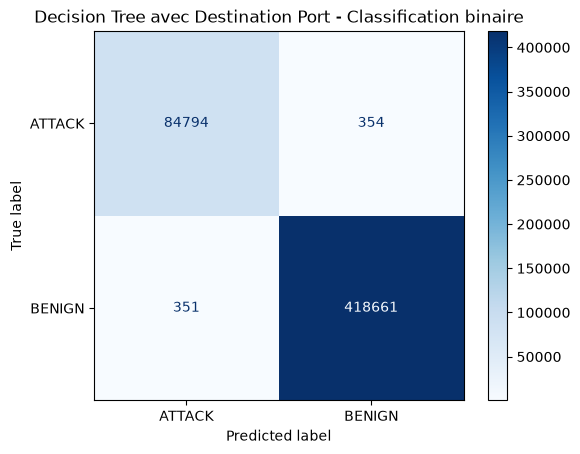

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=encoder.classes_,
    cmap=plt.cm.Blues
    )

plt.title("Decision Tree avec Destination Port - Classification binaire")
plt.show()


In [23]:
# add results to the results list
save_results(
    "Decision Tree",
    "With",
    y_test,
    y_pred,
    train_time
)

Random Forest avec Destination Port :

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [26]:
start_time = time.time()

rf.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

print(f"Training time: {train_time:.2f} seconds")

Training time: 406.36 seconds


In [27]:
y_pred = rf.predict(X_test)

In [28]:
print("Random Forest with Destination Port Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Random Forest with Destination Port Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      0.99      1.00     85148
      BENIGN       1.00      1.00      1.00    419012

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



In [29]:
# metriques 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")

Accuracy: 0.998522
Precision: 0.998984
Recall: 0.999239
F1-Score: 0.999111


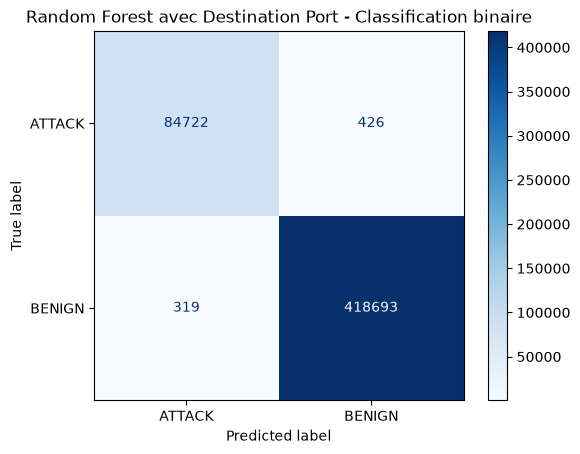

In [30]:
# Matrice de confusion pour le modèle Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=encoder.classes_,
    cmap=plt.cm.Blues
)

plt.title("Random Forest avec Destination Port - Classification binaire")
plt.show()

In [31]:
# Deboggage 
print(type(rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [32]:
# append results to the results list
save_results(
    "Random Forest",
    "With",
    y_test,
    y_pred,
    train_time
)

XGBoost with Destination Port :

In [33]:
# import the library
import xgboost as xgb
from xgboost import XGBClassifier

In [34]:
# Create an XGBoost classifier
xgb = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [35]:
# training the model
start_time = time.time()

xgb.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

print(f"Training time: {train_time:.2f} seconds")

# predicting the test set results
y_pred = xgb.predict(X_test)

Training time: 41.46 seconds


In [36]:
# Classification Report pour le modèle XGBoost
print("XGBoost Classification Report with Destination Port:")

print(classification_report(y_test, y_pred, target_names=encoder.classes_))

XGBoost Classification Report with Destination Port:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     85148
      BENIGN       1.00      1.00      1.00    419012

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



In [37]:
# metrics of the XGBoost model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("XGBoost with Destination Port Classification Metrics:")
print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")

XGBoost with Destination Port Classification Metrics:
Accuracy: 0.998996
Precision: 0.999468
Recall: 0.999325
F1-Score: 0.999396


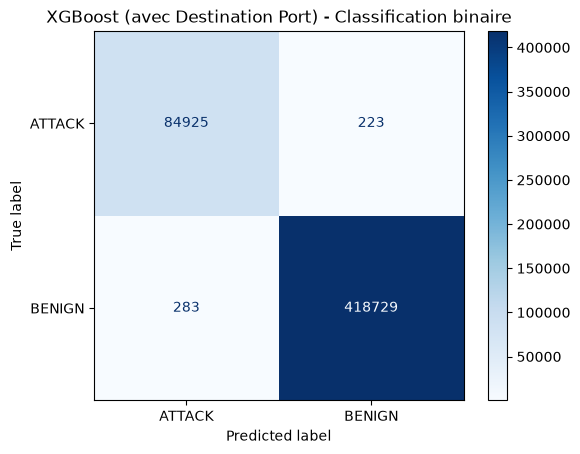

In [38]:
# Confusion Matrix for the XGBoost model with Destination Port
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=encoder.classes_,
    cmap=plt.cm.Blues
)

plt.title("XGBoost (avec Destination Port) - Classification binaire")
plt.show()


In [39]:
# append results to the results list
save_results(
    "XGBoost",
    "With",
    y_test,
    y_pred,
    train_time
)

Nouveau jeu de donnees :

In [40]:
X = df.drop(columns=['Label','Destination Port'])  # 'Destination Port' is another column to drop
y = df['Label']

In [41]:
print(X.shape, y.shape)

(2520798, 68) (2520798,)


In [42]:
from sklearn.preprocessing import LabelEncoder 

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

Decision tree sans Destination Port :

In [44]:
# Creation de modele 
dt = DecisionTreeClassifier(random_state=42)

# entrainement du modele
start_time = time.time()

dt.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

print(f"Training time: {train_time:.2f} seconds")

# Prediction sur l'ensemble de test
y_pred_dt = dt.predict(X_test)

Training time: 264.99 seconds


In [45]:
# Classification Report pour le modèle Decision Tree
print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=encoder.classes_))

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     85148
      BENIGN       1.00      1.00      1.00    419012

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



In [46]:
# metriques 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")


Accuracy: 0.998996
Precision: 0.999468
Recall: 0.999325
F1-Score: 0.999396


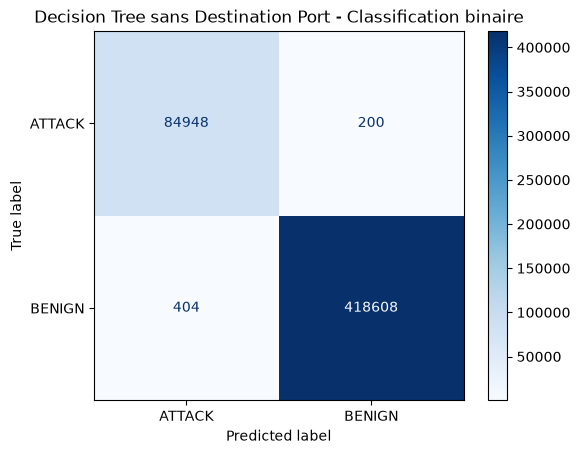

In [47]:
# matrice de confusion pour le modèle Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=encoder.classes_,
    cmap=plt.cm.Blues
)

plt.title("Decision Tree sans Destination Port - Classification binaire")
plt.show()

In [48]:
# append results to the results list
save_results(
    "Decision Tree",
    "Without",
    y_test,
    y_pred,
    train_time
)

Random Forest Sans Destination Port :

In [49]:
# Creation du modele

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Entrainement du modele
start_time = time.time()

rf.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

print(f"Training time: {train_time:.2f} seconds")

# prediction sur l'ensemble de test
y_pred_rf = rf.predict(X_test)

Training time: 406.55 seconds


In [50]:
# Classification Report pour le modèle Random Forest
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=encoder.classes_))

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     85148
      BENIGN       1.00      1.00      1.00    419012

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



In [51]:
# metriques 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")

Accuracy: 0.998996
Precision: 0.999468
Recall: 0.999325
F1-Score: 0.999396


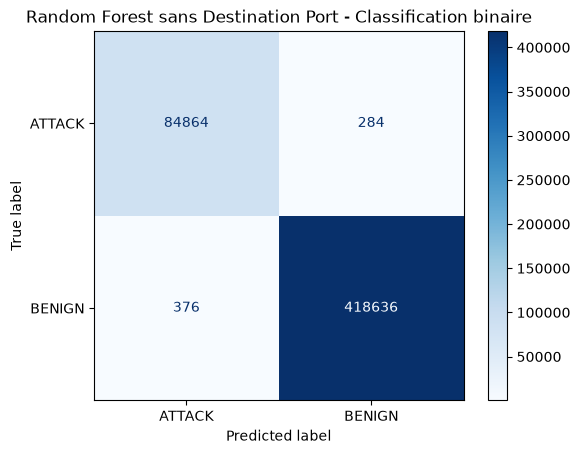

In [52]:
# Confusion Matrix pour le modele Random Forest

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=encoder.classes_,
    cmap=plt.cm.Blues
)

plt.title("Random Forest sans Destination Port - Classification binaire")
plt.show()

In [53]:
# random forest list of results
save_results(
    "Random Forest",
    "Without",
    y_test,
    y_pred,
    train_time
)

XGBoost without Destination Port:

In [54]:
# Import the XGBClassifier from xgboost
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [55]:
# Creation du modele XGBoost
xgb = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

In [56]:
start_time = time.time()

xgb.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

print(f"Training time: {train_time:.2f} seconds")

Training time: 43.80 seconds


In [57]:
# Prediction sur l'ensemble de test
y_pred_xgb = xgb.predict(X_test)

In [58]:
# Affichage du rapport de classification pour le modèle XGBoost
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=encoder.classes_))

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      0.99      1.00     85148
      BENIGN       1.00      1.00      1.00    419012

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



In [59]:
# metriques
accuracy = accuracy_score(y_test, y_pred_rf)    
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")

Accuracy: 0.998691
Precision: 0.999322
Recall: 0.999103
F1-Score: 0.999212


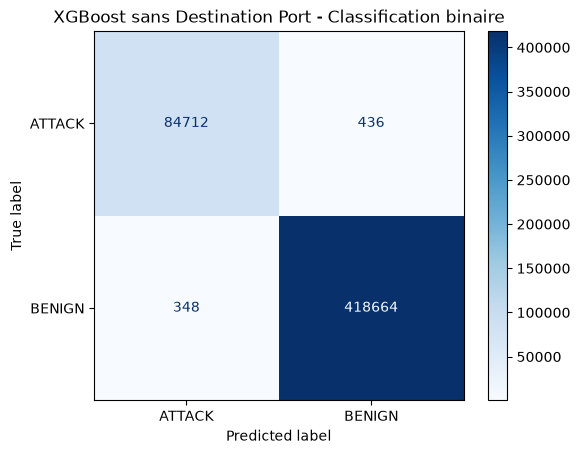

In [60]:
# Matrice de confusion pour le modèle XGBoost
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=encoder.classes_,
    cmap=plt.cm.Blues
)

plt.title("XGBoost sans Destination Port - Classification binaire")
plt.show()

In [61]:
# append results to the results list
save_results(
    "XGBoost",
    "Without",
    y_test,
    y_pred,
    train_time
)

Comparing the results :

In [62]:
# comparison des performances des trois modèles avec et sans la colonne "Destination Port"
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Destination Port,Accuracy,Precision,Recall,F1-score,Macro-F1,Train Time (s)
0,Decision Tree,With,0.998602,0.999155,0.999162,0.999159,0.997509,358.810867
1,Random Forest,With,0.998522,0.998984,0.999239,0.999111,0.997367,406.355253
2,XGBoost,With,0.998996,0.999468,0.999325,0.999396,0.998213,41.459690
3,Decision Tree,Without,0.998996,0.999468,0.999325,0.999396,0.998213,264.993798
4,Random Forest,Without,0.998996,0.999468,0.999325,0.999396,0.998213,406.550184
5,XGBoost,Without,0.998996,0.999468,0.999325,0.999396,0.998213,43.802643
